# StackOverflow Developer Survey 2024 – A CRISP-DM Analysis
This notebook analyzes the official data from the StackOverflow Developer Survey 2024. The goal is to understand the economic drivers behind software developer salaries and train a predictive model.

### Our 3 Business Questions:
1. **The Tech-Stack Leverage:** Does incorporating Python into your tech stack yield a noticeable financial advantage compared to other technologies?
2. **The Flexibility Question:** How is the tech workforce distributed between Remote, Hybrid, and In-Person roles, and does it impact compensation?
3. **Salary Prediction:** Can we accurately predict a developer's annual salary based on country, experience, and work modality?

In [1]:
# Import all required libraries (sorted according to PEP8 guidelines)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Set unified visual style for plots
sns.set_theme(style="whitegrid")

## 1. Data Understanding
In this phase, we load the dataset directly from the source and analyze its structure, dimensions, and the distribution of missing values (`NaN`) to plan our data cleaning strategy.

In [2]:
# Define source URL for streaming the dataset directly from GitHub
DATA_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2024/results.csv"

# Select only relevant columns to optimize memory usage
COLUMNS_OF_INTEREST = [
    "Country",
    "YearsCodePro",
    "Employment",
    "RemoteWork",
    "LanguageHaveWorkedWith",
    "OrgSize",
    "ConvertedCompYearly",
]

print("Loading dataset from GitHub... This might take a moment.")
df_raw = pd.read_csv(DATA_URL, usecols=COLUMNS_OF_INTEREST)
print(f"Dataset successfully loaded! Dimensions: {df_raw.shape}")

# Inspect the amount of missing values per column
print("\nMissing values per column:")
print(df_raw.isnull().sum())

Loading dataset from GitHub... This might take a moment.
Dataset successfully loaded! Dimensions: (65437, 7)

Missing values per column:
Employment                    0
RemoteWork                10631
YearsCodePro              13827
OrgSize                   17957
Country                    6507
LanguageHaveWorkedWith     5692
ConvertedCompYearly       42002
dtype: int64


## 2. Data Preparation & Handling of Missing Values

### Our Cleaning Strategy (Rationale):
1. **Target Variable (`ConvertedCompYearly`):** Rows with missing salaries are completely dropped. Since we are answering financial questions and training an ML model, imputing missing values (e.g., with mean/median) would heavily bias our results.
2. **Professional Experience (`YearsCodePro`):** Text values like "Less than 1 year" or "More than 50 years" are mapped to numeric values (0 and 50) so algorithms can process them. Remaining missing values are removed.
3. **Outlier Handling:** Survey data often contains unrealistic joke entries (e.g., 1 USD or several million USD). We trim the data at the 1st and 99th percentiles to protect our model from extreme distortion.
4. **Categorical Variables:** For Question 1, we create a logical flag (`Uses_Python`). For the later ML model, we will use One-Hot Encoding.

In [3]:
def clean_developer_data(df_input):
    """Cleans the StackOverflow survey dataset for analysis purposes.

    Drops missing target values, maps professional experience to numeric,
    and removes remaining rows with missing critical features.

    Parameters:
    df_input (pd.DataFrame): The uncleaned raw input DataFrame.

    Returns:
    pd.DataFrame: Cleaned DataFrame with formatted features.
    """
    # Drop rows without salary information to avoid bias
    df_temp = df_input.dropna(subset=["ConvertedCompYearly"]).copy()

    # Map text experience boundaries to numeric string values
    experience_mapping = {"Less than 1 year": "0", "More than 50 years": "50"}
    df_temp["YearsCodePro"] = df_temp["YearsCodePro"].replace(
        experience_mapping
    )

    # Convert experience column to numeric data type
    df_temp["YearsCodePro"] = pd.to_numeric(
        df_temp["YearsCodePro"], errors="coerce"
    )

    # Drop records that lack valid experience data after conversion
    df_temp = df_temp.dropna(subset=["YearsCodePro"])

    # Create binary feature for Question 1 (Python usage)
    df_temp["Uses_Python"] = df_temp["LanguageHaveWorkedWith"].str.contains(
        "Python", na=False, case=False
    )

    return df_temp


def remove_salary_outliers(
    df_input, lower_percentile=0.01, upper_percentile=0.99
):
    """Removes extreme salary outliers using lower and upper quantiles.

    Protects machine learning models from being skewed by unrealistic 
    or joke entries.

    Parameters:
    df_input (pd.DataFrame): Dataset containing the salary column.
    lower_percentile (float): Lower threshold limit (default: 1%).
    upper_percentile (float): Upper threshold limit (default: 99%).

    Returns:
    pd.DataFrame: Filtered dataset without extreme outliers.
    """
    low_val = df_input["ConvertedCompYearly"].quantile(lower_percentile)
    high_val = df_input["ConvertedCompYearly"].quantile(upper_percentile)

    df_filtered = df_input[
        (df_input["ConvertedCompYearly"] >= low_val)
        & (df_input["ConvertedCompYearly"] <= high_val)
    ]
    return df_filtered


# Execute modular functions to clean the dataset
df_clean = clean_developer_data(df_raw)
df_clean = remove_salary_outliers(df_clean)

print(f"Original row count: {df_raw.shape[0]}")
print(f"Cleaned row count available for analysis: {df_clean.shape[0]}")

Original row count: 65437
Cleaned row count available for analysis: 22877


## 3. Explorative Data Analysis (EDA)

In this phase, we investigate our data visually and statistically to find answers to our first two business questions. We utilize boxplots and violinplots to make the distributions and potential salary differences visible.

=== ANALYSIS QUESTION 1: The Python Leverage ===
                     mean   median  count
Uses_Python                              
False        75961.343798  64444.0  11722
True         81490.776871  67666.0  11155


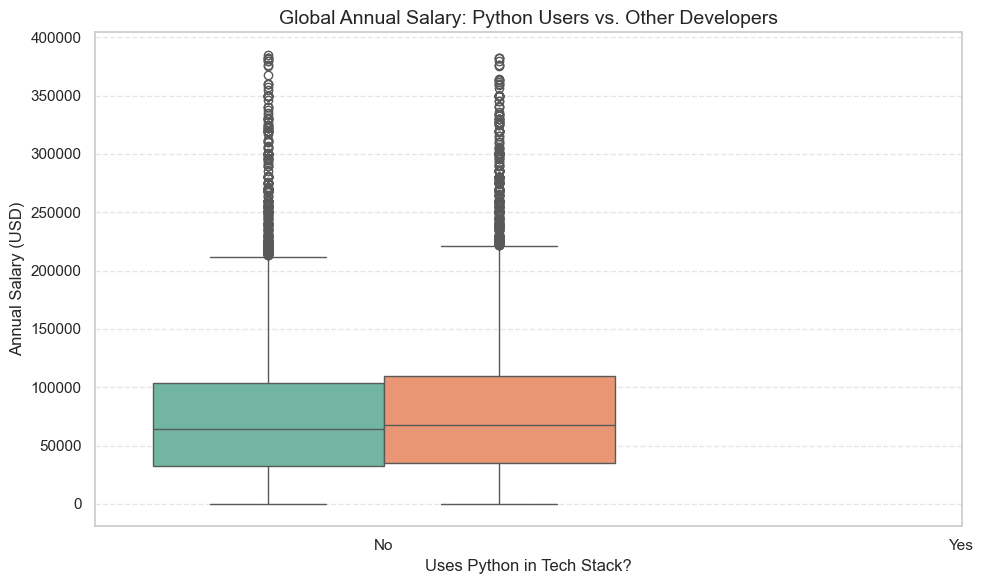


=== ANALYSIS QUESTION 2: Work Modality and Compensation ===
Global distribution of work modalities (in %):
RemoteWork
Hybrid (some remote, some in-person)    42.577288
Remote                                  40.718877
In-person                               16.703835
Name: proportion, dtype: float64


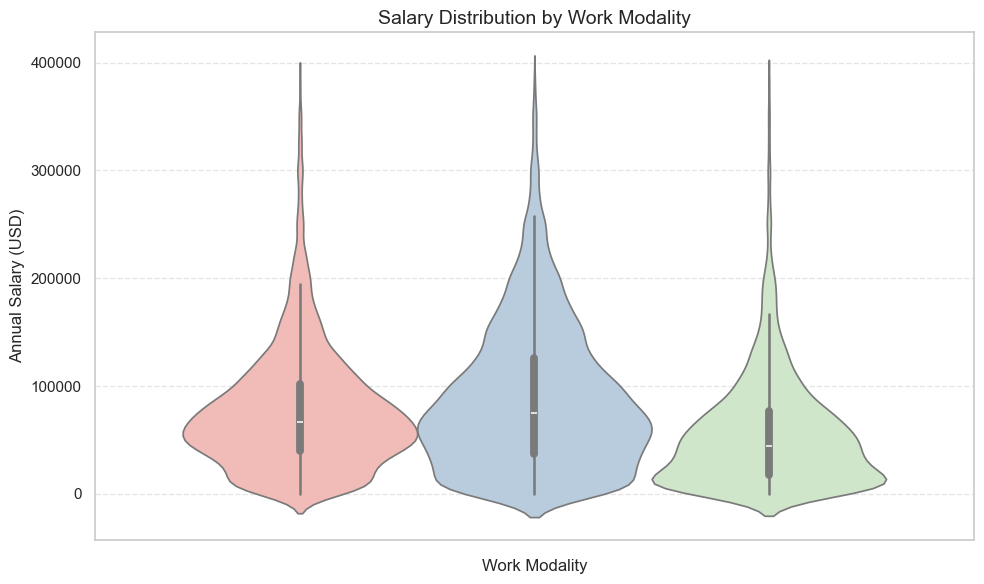

In [7]:
# --- QUESTION 1: Does the Python stack provide a financial leverage? ---
print("=== ANALYSIS QUESTION 1: The Python Leverage ===")

# Compute descriptive statistics for both groups
python_stats = df_clean.groupby("Uses_Python")["ConvertedCompYearly"].agg(
    ["mean", "median", "count"]
)
print(python_stats)

# Generate boxplot visualization for Question 1
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean, hue="Uses_Python", y="ConvertedCompYearly", palette="Set2",legend=False
)
plt.title("Global Annual Salary: Python Users vs. Other Developers", fontsize=14)
plt.xlabel("Uses Python in Tech Stack?", fontsize=12)
plt.ylabel("Annual Salary (USD)", fontsize=12)
plt.xticks([0, 1], ["No", "Yes"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# --- QUESTION 2: Remote, Hybrid, or In-Person - Who earns more? ---
print("\n=== ANALYSIS QUESTION 2: Work Modality and Compensation ===")

# Drop missing values in the remote work column for this specific analysis
df_remote = df_clean.dropna(subset=["RemoteWork"])

# Calculate the percentage distribution of work modalities worldwide
remote_counts = df_remote["RemoteWork"].value_counts(normalize=True) * 100
print("Global distribution of work modalities (in %):")
print(remote_counts)

# Generate violin plot visualization for Question 2
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_remote, hue="RemoteWork", y="ConvertedCompYearly", palette="Pastel1",legend=False
)
plt.title("Salary Distribution by Work Modality", fontsize=14)
plt.xlabel("Work Modality", fontsize=12)
plt.ylabel("Annual Salary (USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Modeling & Evaluation (Question 3)

In this phase, we train a `RandomForestRegressor` to predict annual compensation. 
Categorical text variables (`Country`, `RemoteWork`) are transformed using One-Hot Encoding. The model is trained on 80% of the data and tested on the remaining 20%.

Finally, we simulate a **new scenario** to demonstrate the practical value of the model.

In [5]:
# Define features and the target variable for the predictive model
ml_features = ["Country", "YearsCodePro", "RemoteWork"]
X = df_clean[ml_features].copy()
y = df_clean["ConvertedCompYearly"]

# Convert categorical features into numeric flags using One-Hot Encoding
X = pd.get_dummies(X, columns=["Country", "RemoteWork"], drop_first=True)

# Split data into 80% training and 20% testing sets (reproducible seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train.shape}")

# Initialize and fit the Random Forest Regressor
print("Training the Random Forest model... Please wait.")
model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print("Model successfully trained!")

# Evaluate performance metrics on the unseen test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== MODEL PERFORMANCE METRICS ===")
print(f"R² Score (Explained Variance): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f} USD")


# --- SCENARIO SIMULATION ---
print("\n=== APPLICATION: PREDICTION FOR A NEW SCENARIO ===")
# Scenario: A developer based in Germany, with 5 years of experience, working fully remote.

# Initialize an empty single-row DataFrame matching the exact training columns schema
new_developer = pd.DataFrame(0, index=[0], columns=X.columns)

# Assign feature inputs for the custom profile
new_developer["YearsCodePro"] = 5

# Set appropriate categorical dummy flags to 1 if they exist in the training structure
if "Country_Germany" in new_developer.columns:
    new_developer["Country_Germany"] = 1
if "RemoteWork_Remote" in new_developer.columns:
    new_developer["RemoteWork_Remote"] = 1

# Generate prediction from the trained model
predicted_salary = model.predict(new_developer)[0]

print("Profile: Germany, 5 Years Experience, Fully Remote")
print(f"Predicted Fair Annual Market Salary: ${predicted_salary:,.2f} USD")

Training features shape: (18301, 163)
Training the Random Forest model... Please wait.
Model successfully trained!

=== MODEL PERFORMANCE METRICS ===
R² Score (Explained Variance): 0.5243
Mean Absolute Error (MAE): $29,716.21 USD

=== APPLICATION: PREDICTION FOR A NEW SCENARIO ===
Profile: Germany, 5 Years Experience, Fully Remote
Predicted Fair Annual Market Salary: $76,751.68 USD
